In [ ]:
!pip install -q pyomo

In [ ]:
# https://jckantor.github.io/ND-Pyomo-Cookbook/notebooks/01.02-Running-Pyomo-on-Google-Colab.html#installing-pyomo-and-solvers
%%capture
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

In [ ]:
import pyomo.environ as pyo
import numpy as np

def simulation(params, alphas, criteria='demand'):

    # ------------------------
    # Helper: solve one alpha
    # ------------------------
    def solve_one_alpha(alpha, delta_x):
        a = params["a"]
        b = params["b"]
        pi = params["pi"]
        Dbar = np.array(params["Dbar"], dtype=float)
        Ds = params["Ds"]
        n = len(Dbar)
        k = params['k']

        m = pyo.ConcreteModel()
        m.I = pyo.RangeSet(0, n-1)

        # variables (0 ≤ D_i ≤ Dbar_i)
        m.D = pyo.Var(m.I, bounds=lambda m,i: (0, float(Dbar[i])))

        # price
        def price(m, i):
            return a * m.D[i] + (b - a * Dbar[i])

        # objective: profit
        def obj_rule(m):
            return pi * sum(k[i] * m.D[i] for i in m.I) \
                   - sum(k[i] * price(m,i) * m.D[i] for i in m.I)
        m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

        # capacity
        m.cap = pyo.Constraint(expr=sum(k[i] * m.D[i] for i in m.I) <= Ds)

        # fairness bound
        bound = (1 - alpha) * delta_x

        # fairness: |Di/Dbar_i - Dj/Dbar_j| ≤ bound
        def f_up(m, i, j):
            return  m.D[i]/Dbar[i] - m.D[j]/Dbar[j] <= bound
        def f_dn(m, i, j):
            return -(m.D[i]/Dbar[i] - m.D[j]/Dbar[j]) <= bound

        m.fair_up = pyo.Constraint(m.I, m.I,
            rule=lambda m,i,j: f_up(m,i,j) if i < j else pyo.Constraint.Skip)
        m.fair_dn = pyo.Constraint(m.I, m.I,
            rule=lambda m,i,j: f_dn(m,i,j) if i < j else pyo.Constraint.Skip)

        # solve
        solver = pyo.SolverFactory("ipopt")
        solver.solve(m, tee=False)

        # extract solution
        D = np.array([pyo.value(m.D[i]) for i in m.I])
        p = a*D + (b - a*Dbar)
        U = 0.5*a*D**2
        profit = pyo.value(m.obj)

        return dict(D=D, p=p, U=U, profit=profit)

    # ============================================
    # STEP 1: baseline alpha=0 → compute delta_x
    # ============================================
    sol0 = solve_one_alpha(alpha=0, delta_x=1e6)  # ignore fairness
    D0 = sol0["D"]
    Dbar = np.array(params["Dbar"], dtype=float)

    # demand fairness baseline Δ
    delta_x = max(
        abs(D0[i]/Dbar[i] - D0[j]/Dbar[j])
        for i in range(len(Dbar)) for j in range(i+1, len(Dbar))
    )

    # ============================================
    # STEP 2: loop over alphas and store results
    # ============================================
    res = {"alpha": [], "D": [], "p": [], "U": [], "profit": []}

    for alpha in alphas:
        sol = solve_one_alpha(alpha, delta_x)

        res["alpha"].append(alpha)
        res["D"].append(sol["D"])
        res["p"].append(sol["p"])
        res["U"].append(sol["U"])
        res["profit"].append(sol["profit"])

    return res


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_plot(params, res, ncol=3, regime_bounds=None):
    if regime_bounds is None:
        regime_bounds = []

    alpha_list = np.array(res["alpha"])
    n = len(res["D"][0])   # number of customers
    k = np.array(params['k'])

    lw = 2
    fig = plt.figure(figsize=(28, 5))

    # ---------------------------------------------------------
    # Grid: 1 row × 4 columns
    # First column is split into 4 rows
    # ---------------------------------------------------------
    gs = fig.add_gridspec(1, 4, wspace=0.25)

    gs0 = gs[0, 0].subgridspec(4, 1, hspace=0.12)
    ax0_pi  = fig.add_subplot(gs0[0])
    ax0_sw  = fig.add_subplot(gs0[3], sharex=ax0_pi)
    ax0_u   = fig.add_subplot(gs0[1], sharex=ax0_pi)
    ax0_nsw = fig.add_subplot(gs0[2], sharex=ax0_pi)

    ax_p = fig.add_subplot(gs[0, 1])
    ax_d = fig.add_subplot(gs[0, 2])
    ax_u_i = fig.add_subplot(gs[0, 3])

    # ---------------------------------------------------------
    # 1. Profit, utilities, welfare
    # ---------------------------------------------------------
    profit_list = np.array(res["profit"])
    U_total_list = np.array([
        sum(k[i] * U[i] for i in range(len(k)))
        for U in res["U"]
    ])

    NSW_list, SW_list = [], []
    for t in range(len(res["U"])):
        U_vec = np.array(res["U"][t])

        if np.all(U_vec > 0):
            NSW_list.append(np.sum(k * np.log(U_vec)))
        else:
            NSW_list.append(-np.inf)

        SW_list.append(U_total_list[t] + profit_list[t])

    NSW_list = np.array(NSW_list)
    SW_list  = np.array(SW_list)

    # ---- Row 1: Profit
    l_pi, = ax0_pi.plot(alpha_list, profit_list, 'r', lw=lw, label=r'$\Pi$')
    ax0_pi.set_xlim(0, 1)
    ax0_pi.tick_params(labelbottom=False)

    # ---- Row 4: NSW
    l_nsw, = ax0_nsw.plot(alpha_list, NSW_list, color='purple', lw=lw, label=r'$W_{CNW}$')
    ax0_nsw.set_xlim(0, 1)
    ax0_nsw.tick_params(labelbottom=False)


    # ---- Row 3: Total utility
    l_Utot, = ax0_u.plot(alpha_list, U_total_list, 'g', lw=lw, label=r'$U$')
    ax0_u.set_xlim(0, 1)
    ax0_u.tick_params(labelbottom=False)

    # ---- Row 2: Social welfare
    l_sw, = ax0_sw.plot(alpha_list, SW_list, color='blue', lw=lw, label=r'$W_{SW}$')
    ax0_sw.set_xlim(0, 1)
    ax0_sw.set_xlabel(r'$\alpha$', fontsize=24)


    _fontsize = 20
    # Figure-level legend (for the split first column)
    fig.legend(
        handles=[l_pi, l_nsw, l_Utot, l_sw],
        labels=[r'$\Pi$', r'$W_{CNW}$', r'$U$', r'$W_{SW}$', ],
        loc='upper left',
        bbox_to_anchor=(0.135, 1.11),
        ncol=2,
        fontsize=_fontsize,
        frameon=True,
    )

    # ---------------------------------------------------------
    # 2. Prices p_i (single axis)
    # ---------------------------------------------------------
    p_mat = np.array(res["p"])
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(max(n, 3))]
    colors = [colors[1]] + [colors[0]] + colors[2:]

    for i in range(n):
        ax_p.plot(alpha_list, p_mat[:, i],
                  label=fr'$p_{i+1}$',
                  lw=lw, color=colors[i])

    ax_p.set_xlim(0, 1)
    ax_p.set_xlabel(r'$\alpha$', fontsize=24)
    ax_p.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01),
                ncol=ncol, fontsize=_fontsize, frameon=True)

    # ---------------------------------------------------------
    # 3. Demands D_i with dashed Dbar_i (single axis)
    # ---------------------------------------------------------
    D_mat = np.array(res["D"])
    Dbar = np.array(params["Dbar"])

    for i in range(n):
        ax_d.plot(alpha_list, D_mat[:, i],
                  label=fr'$D_{i+1}$',
                  lw=lw, color=colors[i])
        ax_d.axhline(Dbar[i], ls='--', lw=1.5, color=colors[i])

    ax_d.set_xlim(0, 1)
    ax_d.set_xlabel(r'$\alpha$', fontsize=24)
    ax_d.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01),
                ncol=ncol, fontsize=_fontsize, frameon=True)

    # ---------------------------------------------------------
    # 4. Utilities U_i (single axis)
    # ---------------------------------------------------------
    U_mat = np.array(res["U"])
    for i in range(n):
        ax_u_i.plot(alpha_list, U_mat[:, i],
                    label=fr'$U_{i+1}$',
                    lw=lw, color=colors[i])

    ax_u_i.set_xlim(0, 1)
    ax_u_i.set_xlabel(r'$\alpha$', fontsize=24)
    ax_u_i.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01),
                  ncol=ncol, fontsize=_fontsize, frameon=True)

    # ---------------------------------------------------------
    # Regime bounds
    # ---------------------------------------------------------
    if regime_bounds:
        for bound in regime_bounds:
            for ax in [ax0_pi, ax0_sw, ax0_u, ax0_nsw, ax_p, ax_d, ax_u_i]:
                ax.axvline(bound, color='gray', ls='--', lw=1.2)

    plt.show()


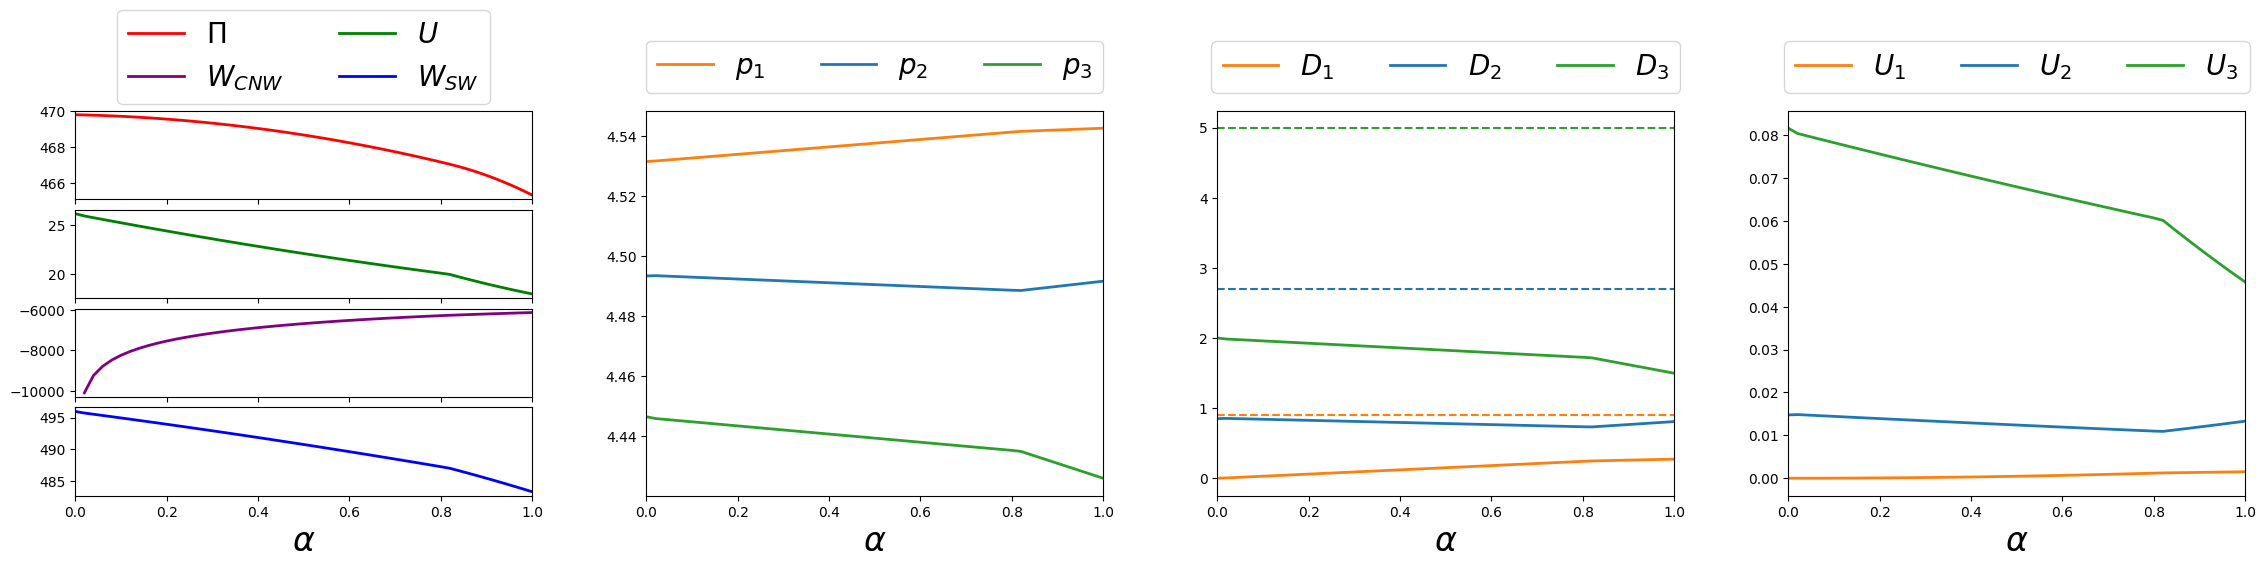

In [ ]:
params = dict(
    a = 0.0408,
    b = 4.5686,
    pi = 5,
    Dbar = [0.907, 2.692, 4.991],
    k = [505, 497, 231],
    Ds = (505 * 0.907 + 497 * 2.692 + 231 * 4.991) * 0.3
)

alphas = [i/50 for i in range(51)]

res = simulation(params, alphas)

draw_plot(params, res, ncol=3, regime_bounds=[])


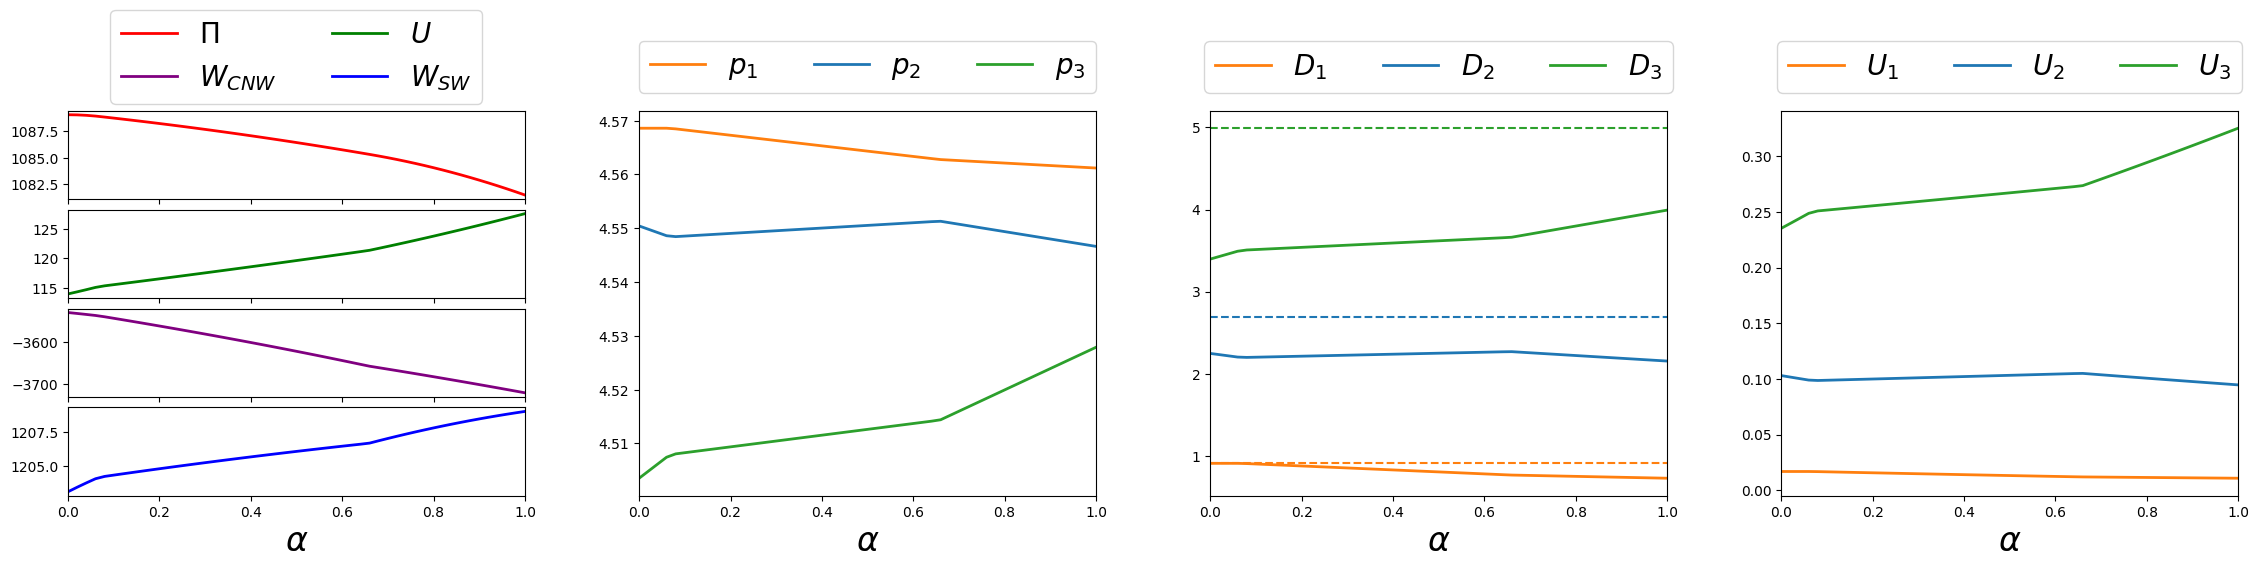

In [ ]:
params = dict(
    a = 0.0408,
    b = 4.5686,
    pi = 5,
    Dbar = [0.907, 2.692, 4.991],
    k = [505, 497, 231],
    Ds = (505 * 0.907 + 497 * 2.692 + 231 * 4.991) * 0.8
)

alphas = [i/50 for i in range(51)]

res = simulation(params, alphas)

draw_plot(params, res, ncol=3, regime_bounds=[])
